# Assignment 2: CNN architectures {-}

This assignment aims at familiarizing you with training and testing the a CNN for an image classification task. You will go through the process of loading data, preprocessing images, building the CNN model, and evaluating its performance.

The assignment rqeuirements include:
- **2.1 (1 point)** Load the dataset.
- **2.2 (1 point)** Process, normalize, and resize the images.
- **2.3 (3 points)** Implement a CNN architecture selected from the models available in the TensorFlow Keras (from this list of models https://www.tensorflow.org/api_docs/python/tf/keras/applications, excluding VGG16 and VGG19).
- **2.4 (1 point)** Train and evaluate the CNN for the image classification task.
- **2.5 (2 points)** Modify the model by introducing enhancements such as skip connections or adjusting hyperparameters of the layers to improve its performance.
- **2.6 (1 point)** Train and evaluate the enhanced model on the test set.
- **2.7 (1 point)** Offer comments and observations regarding the impact of these modifications on the model’s effectiveness.


The dataset you will be working on is The CIFAR-10. This dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment2-notebook.ipynb: Jupyter notebook containing source code.
- ./\<Test-accuracy>-\<StudentID>.txt: accuracy on the test, for example if you get 0.8124 accuracy, the name of this file is 08124-2012345.txt. The file content is left empty.

The submission folder is named DL4AI-\<StudentID>-Assignment2 (e.g., DL4AI-2012345-Assigment2) and then compressed with the same name.


    
### Evaluation {-}
Assignment evaluation will be conducted on how you accomplish the assignment requirements. It is a plus if you have modeling steps other than the basic requirements and achieve an excellent model accuracy. In addition, your code should conform to a Python coding convention such as PEP-8.

EXTRA CREDIT: Top-3 submissions achieving the highest test accuracy will be rewarded an extra credit.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
# !pip install tensorflow_datasets
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10
from keras.layers import Dropout, Flatten, Dense, BatchNormalization
from keras.utils import to_categorical
from keras import Model
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from tensorflow.keras.utils import to_categorical

In [ ]:
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import layers, Sequential, models, layers

In [ ]:
# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.5G5II8_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.5G5II8_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


# Data processing and model training

In [ ]:
# PLEASE DO NOT CHANGE THIS CODE

# Seperate feature X and label Y
X_train, Y_train = cifar10_train["image"], cifar10_train["label"]
X_test, Y_test = cifar10_test["image"], cifar10_test["label"]
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, random_state=99, test_size=0.2)

# Normalize the image data
X_train = X_train/255
X_val = X_val/255
X_test = X_test/255

# Specify the input image size and number of classes
img_width, img_height = 32, 32
nb_classes = 10

# Converts a class vector (integers) to binary class matrix to have one-hot encoding label. For example:
Y_train = to_categorical(Y_train, nb_classes)
Y_val = to_categorical(Y_val, nb_classes)
Y_test = to_categorical(Y_test, nb_classes)

In [ ]:
print("Training set shape: " + str(X_train.shape))
print("validation set shape: " + str(X_val.shape))
print("Test set shape: " + str(X_test.shape))

Training set shape: (40000, 32, 32, 3)
validation set shape: (10000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


# ResNet50

In [ ]:
# Create the base model from pre-trained ResNet50
base_model = tf.keras.applications.ResNet50( weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.summary()

94765736/94765736 [==============================] - 1s 0us/step
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 38, 38, 3)            0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 16, 16, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 16, 16, 64)           256       ['conv1_conv[0][0]']          
 on)                      

In [ ]:
model= models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512,activation='relu'))
model.add(BatchNormalization())
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), metrics=['accuracy'])
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.001)
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

In [ ]:
history =model.fit(X_train, Y_train, epochs=10, validation_data=(X_val, Y_val),
                    callbacks=[reduce_lr, early_stopping], verbose=2)

Epoch 1/10
1250/1250 - 237s - loss: 2.0204 - accuracy: 0.3645 - val_loss: 1.4021 - val_accuracy: 0.5406 - lr: 0.0010 - 237s/epoch - 190ms/step
Epoch 2/10
1250/1250 - 229s - loss: 1.3346 - accuracy: 0.5546 - val_loss: 1.0946 - val_accuracy: 0.6313 - lr: 0.0010 - 229s/epoch - 183ms/step
Epoch 3/10
1250/1250 - 229s - loss: 1.1187 - accuracy: 0.6227 - val_loss: 0.9905 - val_accuracy: 0.6635 - lr: 0.0010 - 229s/epoch - 183ms/step
Epoch 4/10
1250/1250 - 227s - loss: 0.9668 - accuracy: 0.6727 - val_loss: 0.8840 - val_accuracy: 0.6983 - lr: 0.0010 - 227s/epoch - 181ms/step
Epoch 5/10
1250/1250 - 227s - loss: 0.8560 - accuracy: 0.7084 - val_loss: 0.8355 - val_accuracy: 0.7179 - lr: 0.0010 - 227s/epoch - 181ms/step
Epoch 6/10
1250/1250 - 228s - loss: 0.7727 - accuracy: 0.7359 - val_loss: 0.7975 - val_accuracy: 0.7306 - lr: 0.0010 - 228s/epoch - 182ms/step
Epoch 7/10
1250/1250 - 228s - loss: 0.7045 - accuracy: 0.7566 - val_loss: 0.7711 - val_accuracy: 0.7394 - lr: 0.0010 - 228s/epoch - 182ms/step

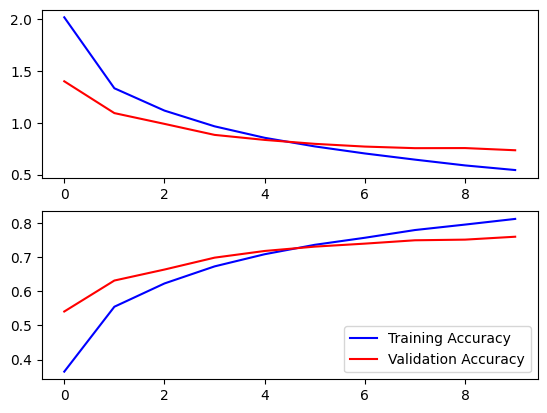

In [ ]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history.history['loss'], color='b',label='Training Loss')
ax[0].plot(history.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [ ]:
# Show the model performance
result = model.evaluate(X_test, Y_test)
print(model.metrics_names)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

313/313 [==============================] - 16s 50ms/step - loss: 0.7324 - accuracy: 0.7551
['loss', 'accuracy']
Loss and accuracy on the test set: loss = 0.7324447631835938, accuracy = 0.7551000118255615


# ResNet50_ver2

In [ ]:
# Create the base model from pre-trained ResNet50
base_model2 = tf.keras.applications.ResNet50( weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model2.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 134, 134, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 64, 64, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 64, 64, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 64, 64, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 66, 66, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 32, 32, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 32, 32, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 32, 32, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 32, 32, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 32, 32, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 32, 32, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 32, 32, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 32, 32, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 32, 32, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model2= models.Sequential()
model2.add(layers.UpSampling2D((2,2)))
model2.add(layers.UpSampling2D((2,2)))
model2.add(base_model2)
model2.add(layers.GlobalAveragePooling2D())
model2.add(layers.Dense(128,activation='relu'))
model2.add(layers.Dropout(0.5))
model2.add(BatchNormalization())
model2.add(layers.Dense(64,activation='relu'))
model2.add(layers.Dropout(0.5))
model2.add(BatchNormalization())
model2.add(layers.Dense(10, activation='softmax'))

In [ ]:
model2.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), metrics=['accuracy'])
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001)
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

In [ ]:
history3 =model2.fit(X_train, Y_train, epochs=32, validation_data=(X_val, Y_val),
                    callbacks=[reduce_lr, early_stopping], verbose=2)

Epoch 1/32
1250/1250 - 186s - 149ms/step - accuracy: 0.2916 - loss: 2.1354 - val_accuracy: 0.7241 - val_loss: 1.1372 - learning_rate: 0.0010
Epoch 2/32
1250/1250 - 162s - 130ms/step - accuracy: 0.5804 - loss: 1.3207 - val_accuracy: 0.8240 - val_loss: 0.7484 - learning_rate: 0.0010
Epoch 3/32
1250/1250 - 142s - 114ms/step - accuracy: 0.7038 - loss: 1.0235 - val_accuracy: 0.8632 - val_loss: 0.5487 - learning_rate: 0.0010
Epoch 4/32
1250/1250 - 142s - 113ms/step - accuracy: 0.7674 - loss: 0.8510 - val_accuracy: 0.8727 - val_loss: 0.5038 - learning_rate: 0.0010
Epoch 5/32
1250/1250 - 143s - 115ms/step - accuracy: 0.8069 - loss: 0.7409 - val_accuracy: 0.8954 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 6/32
1250/1250 - 142s - 113ms/step - accuracy: 0.8281 - loss: 0.6636 - val_accuracy: 0.9038 - val_loss: 0.3484 - learning_rate: 0.0010
Epoch 7/32
1250/1250 - 142s - 114ms/step - accuracy: 0.8497 - loss: 0.5961 - val_accuracy: 0.9131 - val_loss: 0.3141 - learning_rate: 0.0010
Epoch 8/32
12

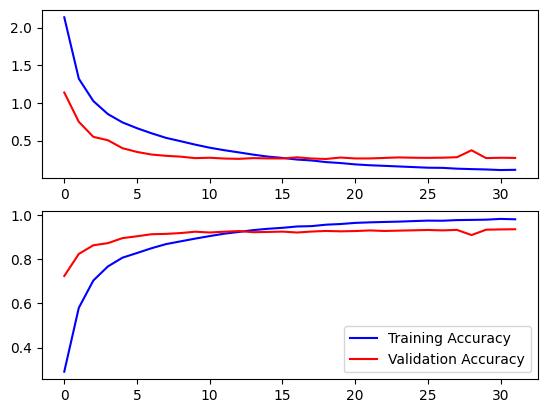

In [ ]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history3.history['loss'], color='b',label='Training Loss')
ax[0].plot(history3.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history3.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history3.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [ ]:
# Show the model performance
result_2 = model2.evaluate(X_test, Y_test)
print(model2.metrics_names)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result_2[0],result_2[1]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9281 - loss: 0.2706
['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 0.2672388255596161, accuracy = 0.9271000027656555


In the second model, I modified the architecture by increasing the input image size from 32x32 to 128x128 using two layers of UpSampling2D and adding two dense layers with 128 and 64 neurons, respectively, before the final softmax layer. These modifications led to a substantial performance improvement, with the model's accuracy rising from 75.5% to 92.7%.

During the optimization process, I observed the impact of progressively increasing the input image size on accuracy. Initially, I increased the image size from 32x32 to 64x64, which boosted the model's accuracy to around 86%. Encouraged by this improvement, I further increased the input size to 128x128, resulting in an accuracy of 91.5%. I attempted an even larger input size of 256x256, but this caused the training process to become excessively slow and eventually led to an out-of-memory error. As a result, I settled on 128x128 for the input size, which struck a good balance between accuracy and computational efficiency.
To further enhance performance, I added two dense layers with 128 and 64 neurons after the base model. This modification helped increase accuracy from 91.5% to 92.7%.

Overall, I found that upsampling allowed the model to process higher-resolution images, enabling it to capture finer spatial details and improving classification accuracy by distinguishing subtle features across classes. However, this also increased computational requirements, as larger images contain more pixel data, leading to longer training times and higher memory consumption. The combination of upsampling and additional dense layers proved effective in boosting the model's ability to generalize while balancing performance and efficiency.